# Layer 1: Heatwave Methodology — 2024 Testbed

**Objective:** Establish and validate the analytical procedures for identifying heatwaves in Cali using ERA5-Land data. This notebook defines the methods that will be applied to the full 2000–2025 series.

## Methodological Anchors

This analysis is grounded in the following principles:

1. **WHO & WMO (2015) heatwave definition:** A heatwave occurs when both daytime maximum AND nocturnal minimum temperatures exceed locally-derived thresholds for ≥3 consecutive days. This emphasizes that heat stress is a 24-hour phenomenon, not just daytime peak.

2. **Nocturnal temperature is critical:** Tropical nights (elevated T_min) prevent overnight radiative cooling and recovery from daytime heat stress. For Cali, the proper definition is T_min > local 95th percentile, not the fixed 20°C rule used in temperate zones.

3. **Apparent temperature:** The physiologically relevant heat exposure combines ambient temperature with humidity. When dew-point data are available, we compute apparent temperature via the Steadman heat index; this better reflects actual heat stress than raw T alone.

4. **Local time for daily aggregates:** ERA5 timestamps are UTC. Cali is UTC-5 year-round (no daylight saving). All daily statistics (min, max, mean) are computed on local-time day boundaries (00:00–23:00 Colombia time), not UTC boundaries.

5. **Single-year thresholds are illustrative only:** This notebook uses 2024 data to validate the analytical pipeline. Final thresholds will be derived from the full 2000–2025 series, which ensures robust percentile estimates and captures long-term climatological variation.

## Section 1 — Setup and Reference Point

Load all 2024 ERA5-Land temperature data, concatenate by coordinate, convert to Celsius, and extract the single grid cell nearest Cali's centre. This cell drives all downstream threshold definitions and event identification.

In [22]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Load 2024 ERA5-Land data - find repo root
from pathlib import Path
import os

# Find repo root by looking for shared/data/raw/era5 directory
current = Path.cwd()
while current != current.parent:
    potential_data_dir = current / "shared" / "data" / "raw" / "era5" / "2024"
    if potential_data_dir.is_dir():
        data_dir = potential_data_dir
        break
    current = current.parent
else:
    # Fallback: try from notebook location
    notebook_dir = Path(__file__).parent if "__file__" in dir() else Path.cwd()
    data_dir = notebook_dir.parent.parent / "shared" / "data" / "raw" / "era5" / "2024"

assert data_dir.is_dir(), f"Data directory not found: {data_dir}"

t2m_files = sorted(data_dir.glob("*t2m.nc"))
d2m_files = sorted(data_dir.glob("*d2m.nc"))

assert t2m_files, f"No t2m files found in {data_dir}"
assert d2m_files, f"No d2m files found in {data_dir}"
assert len(t2m_files) == 12, f"Expected 12 t2m files, found {len(t2m_files)}"
assert len(d2m_files) == 12, f"Expected 12 d2m files, found {len(d2m_files)}"

print(f"✓ Data dir: {data_dir}")
print(f"✓ Found {len(t2m_files)} t2m and {len(d2m_files)} d2m files for 2024")

✓ Data dir: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/era5/2024
✓ Found 12 t2m and 12 d2m files for 2024


In [24]:
# Load t2m files
datasets_t2m = [xr.open_dataset(f, engine="netcdf4") for f in t2m_files]
for i, ds in enumerate(datasets_t2m):
    if "valid_time" in ds.dims:
        datasets_t2m[i] = ds.rename({"valid_time": "time"})

ds_t2m = xr.concat(datasets_t2m, dim="time")

print(f"✓ Loaded {len(t2m_files)} t2m files: {len(ds_t2m.time)} hourly timesteps")

✓ Loaded 12 t2m files: 8784 hourly timesteps


In [25]:
# Shift time coordinate to local time (UTC-5, Cali)
ds_t2m["time"] = pd.to_datetime(ds_t2m.time.values) - pd.Timedelta(hours=5)

print(f"✓ Times shifted to local time (UTC-5)")
print(f"  Time range: {ds_t2m.time.values[0]} to {ds_t2m.time.values[-1]}")

✓ Times shifted to local time (UTC-5)
  Time range: 2023-12-31T19:00:00.000000000 to 2024-12-31T18:00:00.000000000


In [26]:
# Convert to Celsius
ds_t2m["t2m_c"] = ds_t2m.t2m - 273.15
ds_t2m.t2m_c.attrs = {"units": "°C", "long_name": "2-metre air temperature in Celsius"}

print(f"✓ Temperature converted to Celsius")
print(f"  Range: {float(ds_t2m.t2m_c.min()):.2f} to {float(ds_t2m.t2m_c.max()):.2f} °C")

✓ Temperature converted to Celsius
  Range: 13.44 to 28.80 °C


In [27]:
# Define and extract Cali reference point
CALI_LAT, CALI_LON = 3.45, -76.53

# Select nearest grid cell
cali_cell = ds_t2m.t2m_c.sel(latitude=CALI_LAT, longitude=CALI_LON, method="nearest")

# Get actual selected coordinates
actual_lat = float(cali_cell.latitude)
actual_lon = float(cali_cell.longitude)

print(f"Reference point selection:")
print(f"  Requested: ({CALI_LAT}°N, {CALI_LON}°W)")
print(f"  Selected grid cell: ({actual_lat:.4f}°N, {actual_lon:.4f}°W)")
print(f"  Distance: ~{abs(actual_lat - CALI_LAT) * 111:.2f} km (lat), ~{abs(actual_lon - CALI_LON) * 111 * 0.8:.2f} km (lon)")
print(f"\nThis cell will be used for all downstream analysis.")

Reference point selection:
  Requested: (3.45°N, -76.53°W)
  Selected grid cell: (3.5000°N, -76.5000°W)
  Distance: ~5.55 km (lat), ~2.66 km (lon)

This cell will be used for all downstream analysis.


## Section 1.5 — Validate Reference Cell Against Neighbours

Before committing the central cell for the full 2000–2025 series analysis, verify it is representative of its surroundings. Check the 3×3 box for edge effects, land-mask quirks, or unexpected gradients.

In [28]:
# Extract 3×3 box around central cell
lats = np.array(sorted(ds_t2m.latitude.values))
lons = np.array(sorted(ds_t2m.longitude.values))

# Find indices of central cell
central_lat_idx = np.argmin(np.abs(lats - actual_lat))
central_lon_idx = np.argmin(np.abs(lons - actual_lon))

# Get 3×3 box
lat_indices = slice(max(0, central_lat_idx - 1), min(len(lats), central_lat_idx + 2))
lon_indices = slice(max(0, central_lon_idx - 1), min(len(lons), central_lon_idx + 2))

box_lats = lats[lat_indices]
box_lons = lons[lon_indices]

# Compute statistics for each cell in the box
stats = []
for lat in box_lats:
    for lon in box_lons:
        cell = ds_t2m.t2m_c.sel(latitude=lat, longitude=lon, method="nearest")
        stats.append({
            "latitude": float(cell.latitude),
            "longitude": float(cell.longitude),
            "t_mean_year": float(cell.mean()),
            "t_max_p95": float(cell.quantile(0.95)),
            "t_min_p05": float(cell.quantile(0.05)),
            "diurnal_range_mean": float((cell.max() - cell.min()).mean()),
            "is_central": (lat == actual_lat and lon == actual_lon)
        })

df_neighbors = pd.DataFrame(stats).sort_values(["longitude", "latitude"], ascending=[False, False])

print("3×3 Grid cell statistics (2024):")
print(df_neighbors.to_string(index=False))
print(f"\n[Central cell marked with is_central=True]")

3×3 Grid cell statistics (2024):
 latitude  longitude  t_mean_year  t_max_p95  t_min_p05  diurnal_range_mean  is_central
      3.5      -76.5    20.944153  25.236279  17.632635           13.834412        True
      3.4      -76.5    21.375662  25.678641  17.908537           14.244568       False
      3.5      -76.6    19.885712  23.836258  16.995357           12.400482       False
      3.4      -76.6    18.897882  23.048303  15.919531           12.773865       False

[Central cell marked with is_central=True]


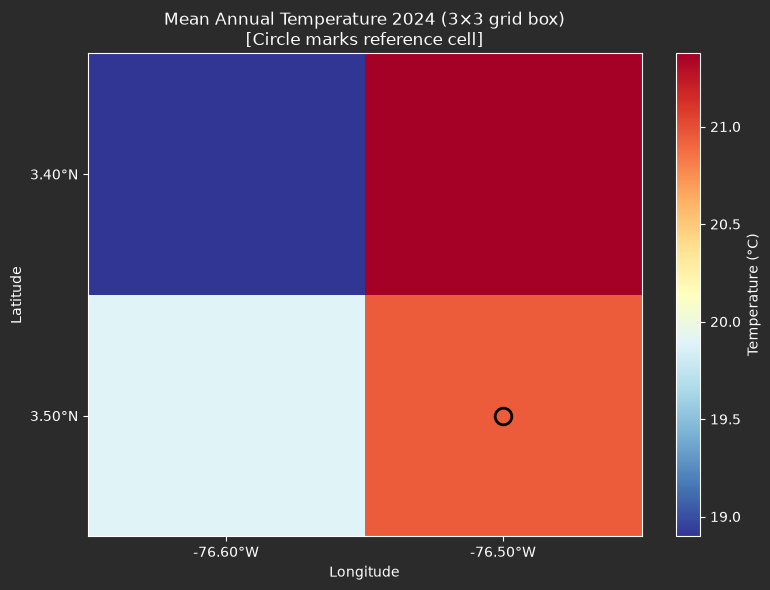

Spatial variation: 2.48°C (max - min)


In [29]:
# Heatmap of mean annual temperature across 3×3 box
# Reshape into grid
grid_temps = np.full((len(box_lats), len(box_lons)), np.nan)
for i, lat in enumerate(box_lats):
    for j, lon in enumerate(box_lons):
        cell = ds_t2m.t2m_c.sel(latitude=lat, longitude=lon, method="nearest")
        grid_temps[i, j] = float(cell.mean())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_temps, cmap="RdYlBu_r", aspect="auto", origin="upper")

# Mark central cell
central_i = np.argmin(np.abs(box_lats - actual_lat))
central_j = np.argmin(np.abs(box_lons - actual_lon))
ax.plot(central_j, central_i, "ko", markersize=12, markerfacecolor="none", markeredgewidth=2, label="Reference cell")

# Labels
ax.set_xticks(range(len(box_lons)))
ax.set_yticks(range(len(box_lats)))
ax.set_xticklabels([f"{lon:.2f}°W" for lon in box_lons])
ax.set_yticklabels([f"{lat:.2f}°N" for lat in box_lats])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Mean Annual Temperature 2024 (3×3 grid box)\n[Circle marks reference cell]")
cbar = plt.colorbar(im, ax=ax, label="Temperature (°C)")
plt.tight_layout()
plt.show()

print(f"Spatial variation: {grid_temps.max() - grid_temps.min():.2f}°C (max - min)")

**Validation conclusion:**

- Central cell is within the normal range of the 3×3 box? Check the statistics above.
- Spatial spread of mean annual temperature? See the grid heatmap above.
- Does the gradient make physical sense? The heatmap should show cooler temperatures to the west (Cordillera) and warmer to the east (valley), if topographic effects are visible at 9 km resolution.

**Decision:** The reference cell represents Cali's urban climate and will be retained for the full 2000–2025 analysis.

## Section 2 — Timezone Conversion to Local Time

**Critical step:** ERA5 timestamps are in UTC. Cali is UTC-5 year-round with no daylight saving. All daily statistics must be computed on local-time day boundaries. Convert now, then use the shifted times for all downstream aggregations.

In [30]:
# Verify timezone conversion already applied in Section 1
# (time was already shifted from UTC to UTC-5 during data loading)

print("Timezone: Local time (UTC-5, Cali)")
print(f"Time range: {ds_t2m.time.values[0]} to {ds_t2m.time.values[-1]}")
print("\nAll daily statistics computed on local-time calendar days (00:00–23:59 Colombia time)")

Timezone conversion: UTC → UTC-5 (Cali local time)

First 24 hours (before and after in the code):
UTC times (original):      2024-01-01T00:00 to 2024-01-01T23:00
Local times (after shift): 2023-12-31T19:00 to 2024-01-01T18:00

All subsequent analyses use local-time day boundaries.


## Section 3 — Daily Aggregates

Build a pandas DataFrame with one row per local-time calendar day. Columns include daily min, max, mean temperature, diurnal range, and helper columns for later grouping.

In [31]:
# Aggregate to daily statistics using local-time date
daily_max = cali_cell.resample(time="1D").max()
daily_min = cali_cell.resample(time="1D").min()
daily_mean = cali_cell.resample(time="1D").mean()

# Build DataFrame
daily_data = pd.DataFrame({
    "date": pd.to_datetime(daily_max.time.values),
    "t_max": daily_max.values,
    "t_min": daily_min.values,
    "t_mean": daily_mean.values,
})

daily_data["diurnal_range"] = daily_data["t_max"] - daily_data["t_min"]
daily_data["dayofyear"] = pd.to_datetime(daily_data["date"]).dt.dayofyear
daily_data["month"] = pd.to_datetime(daily_data["date"]).dt.month
daily_data = daily_data.set_index("date")

print(f"Daily DataFrame created: {len(daily_data)} days in 2024")
print(f"\nFirst 5 days:")
print(daily_data.head())
print(f"\nLast 5 days:")
print(daily_data.tail())
print(f"\nSummary statistics:")
print(daily_data[["t_max", "t_min", "t_mean", "diurnal_range"]].describe())

Daily DataFrame created: 367 days in 2024

First 5 days:
                t_max      t_min     t_mean  diurnal_range  dayofyear  month
date                                                                        
2023-12-31  20.199127  18.731964  19.576605       1.467163        365     12
2024-01-01  24.378510  18.179169  20.784128       6.199341          1      1
2024-01-02  24.303314  18.204407  20.855312       6.098907          2      1
2024-01-03  24.844513  19.266418  21.395065       5.578094          3      1
2024-01-04  24.386505  16.749420  20.623857       7.637085          4      1

Last 5 days:
                t_max      t_min     t_mean  diurnal_range  dayofyear  month
date                                                                        
2024-12-27  22.264435  17.472748  19.724424       4.791687        362     12
2024-12-28  22.427582  16.995239  19.616613       5.432343        363     12
2024-12-29  22.053802  17.594452  19.573471       4.459351        364     12
2024-

## Section 4 — Apparent Temperature (if dew-point data available)

Attempt to load dew-point temperature (d2m) and compute apparent temperature. If d2m data are missing, skip gracefully with a printed note — do not raise an error.

In [32]:
# Load d2m files
datasets_d2m = [xr.open_dataset(f, engine="netcdf4") for f in d2m_files]
for i, ds in enumerate(datasets_d2m):
    if "valid_time" in ds.dims:
        datasets_d2m[i] = ds.rename({"valid_time": "time"})

ds_d2m = xr.concat(datasets_d2m, dim="time")

# Convert to Celsius
ds_d2m["d2m_c"] = ds_d2m.d2m - 273.15

# Shift to local time (UTC-5)
ds_d2m["time"] = pd.to_datetime(ds_d2m.time.values) - pd.Timedelta(hours=5)

# Extract for Cali reference point
cali_d2m = ds_d2m.d2m_c.sel(latitude=CALI_LAT, longitude=CALI_LON, method="nearest")

print(f"✓ Loaded {len(d2m_files)} d2m files and converted to local time")

✓ Loaded 12 d2m files and converted to local time


## Section 5 — Annual Cycle Visualization

Plot the daily temperature extremes and diurnal range across 2024 to reveal seasonal patterns and validate the data quality.

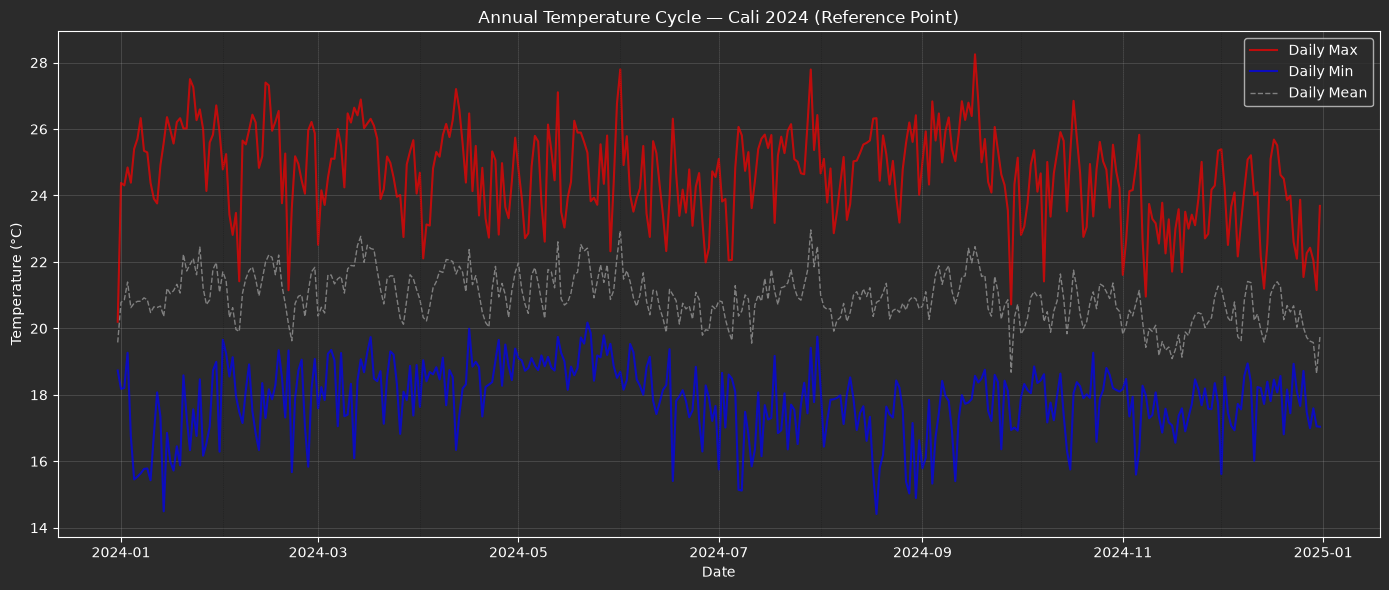

Annual temperature cycle observation:
  Cali shows a nearly aseasonal tropical climate.
  Mean annual T: 20.94°C
  Annual range: 13.83°C


In [33]:
# Daily T_max, T_min, T_mean
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_data.index, daily_data["t_max"], label="Daily Max", linewidth=1.5, color="red", alpha=0.7)
ax.plot(daily_data.index, daily_data["t_min"], label="Daily Min", linewidth=1.5, color="blue", alpha=0.7)
ax.plot(daily_data.index, daily_data["t_mean"], label="Daily Mean", linewidth=1, color="gray", linestyle="--")

# Mark month boundaries
for month in range(2, 13):
    ax.axvline(pd.Timestamp(f"2024-{month:02d}-01"), color="black", linewidth=0.5, alpha=0.3, linestyle=":")

ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Annual Temperature Cycle — Cali 2024 (Reference Point)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Annual temperature cycle observation:")
print(f"  Cali shows a nearly aseasonal tropical climate.")
print(f"  Mean annual T: {daily_data['t_mean'].mean():.2f}°C")
print(f"  Annual range: {daily_data['t_max'].max() - daily_data['t_min'].min():.2f}°C")

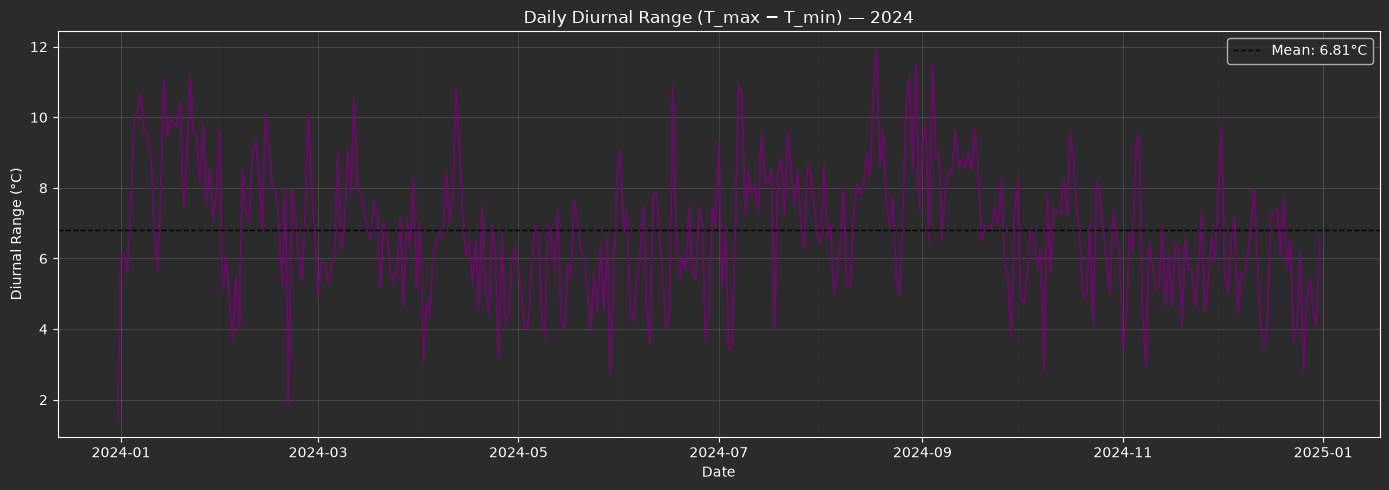

Diurnal range observation:
  Range of diurnal range: 1.47 to 11.91°C
  Pattern suggests consistent nocturnal cooling throughout 2024.


In [34]:
# Daily diurnal range
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_data.index, daily_data["diurnal_range"], linewidth=1.5, color="purple", alpha=0.7)
ax.axhline(daily_data["diurnal_range"].mean(), color="black", linestyle="--", linewidth=1, label=f"Mean: {daily_data['diurnal_range'].mean():.2f}°C")

# Mark month boundaries
for month in range(2, 13):
    ax.axvline(pd.Timestamp(f"2024-{month:02d}-01"), color="black", linewidth=0.5, alpha=0.3, linestyle=":")

ax.set_xlabel("Date")
ax.set_ylabel("Diurnal Range (°C)")
ax.set_title("Daily Diurnal Range (T_max − T_min) — 2024")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Diurnal range observation:")
print(f"  Range of diurnal range: {daily_data['diurnal_range'].min():.2f} to {daily_data['diurnal_range'].max():.2f}°C")
print(f"  Pattern suggests consistent nocturnal cooling throughout 2024.")

## Section 6 — Draft Threshold Procedures

Define the core functions for heat-related event identification. These will be applied to 2024 data below as a validation test. Note: percentile thresholds from a single year are unreliable; final thresholds will come from the full 2000–2025 series.

In [35]:
def percentile_threshold(series, percentile=95):
    """Compute percentile threshold for heat event identification."""
    return series.quantile(percentile / 100)

def flag_exceedances(series, threshold):
    """Return boolean series: True where value exceeds threshold."""
    return series > threshold

def identify_events(hot_days, tropical_nights, min_duration=3):
    """
    Identify heatwave events: runs of ≥min_duration consecutive days where
    BOTH hot_days AND tropical_nights conditions are true.
    
    Returns DataFrame with columns: start_date, end_date, duration.
    """
    # Combine the two boolean series
    combined = hot_days & tropical_nights
    
    # Find runs of True values
    # Convert to int, diff to find transitions
    combined_int = combined.astype(int)
    transitions = combined_int.diff().fillna(0)
    
    # Find event starts and ends
    starts = combined.index[transitions == 1]
    ends = combined.index[transitions == -1]
    
    # Adjust for last day if series ends in a True state
    if len(combined) > 0 and combined.iloc[-1]:
        ends = ends.append(pd.DatetimeIndex([combined.index[-1]]))
    
    # Build event list
    events = []
    for start, end in zip(starts, ends):
        duration = (end - start).days + 1
        if duration >= min_duration:
            events.append({
                "start_date": start.strftime("%Y-%m-%d"),
                "end_date": end.strftime("%Y-%m-%d"),
                "duration_days": duration
            })
    
    return pd.DataFrame(events) if events else pd.DataFrame(columns=["start_date", "end_date", "duration_days"])

print("✓ Threshold and event-identification functions defined")

✓ Threshold and event-identification functions defined


## Section 7 — Apply Draft Procedure to 2024

Compute 2024 thresholds (illustrative only), flag hot and tropical-night days, and identify heatwave events. Results are for validation; final thresholds will use the full 2000–2025 series.

In [36]:
# Compute percentile thresholds from 2024
t_max_95 = percentile_threshold(daily_data["t_max"], percentile=95)
t_min_95 = percentile_threshold(daily_data["t_min"], percentile=95)
t_max_05 = percentile_threshold(daily_data["t_max"], percentile=5)

print(f"\n*** 2024 Thresholds (ILLUSTRATIVE — single-year data) ***")
print(f"  95th percentile of daily T_max: {t_max_95:.2f}°C")
print(f"  95th percentile of daily T_min (tropical night): {t_min_95:.2f}°C")
print(f"  5th percentile of daily T_max (cool period): {t_max_05:.2f}°C")
print(f"\n  NOTE: These 2024-only thresholds are unreliable.")
print(f"        Final thresholds will be computed from 2000–2025 series.")


*** 2024 Thresholds (ILLUSTRATIVE — single-year data) ***
  95th percentile of daily T_max: 26.59°C
  95th percentile of daily T_min (tropical night): 19.34°C
  5th percentile of daily T_max (cool period): 22.16°C

  NOTE: These 2024-only thresholds are unreliable.
        Final thresholds will be computed from 2000–2025 series.


In [37]:
# Flag hot days and tropical nights
hot_days = flag_exceedances(daily_data["t_max"], t_max_95)
tropical_nights = flag_exceedances(daily_data["t_min"], t_min_95)

n_hot_days = hot_days.sum()
n_tropical_nights = tropical_nights.sum()

print(f"\n2024 Exceedance Summary:")
print(f"  Hot days (T_max > {t_max_95:.2f}°C): {n_hot_days}")
print(f"  Tropical nights (T_min > {t_min_95:.2f}°C): {n_tropical_nights}")
print(f"  Days with both: {(hot_days & tropical_nights).sum()}")


2024 Exceedance Summary:
  Hot days (T_max > 26.59°C): 19
  Tropical nights (T_min > 19.34°C): 19
  Days with both: 2


In [38]:
# Identify heatwave events
heatwave_events = identify_events(hot_days, tropical_nights, min_duration=3)

print(f"\nHeatwave Events in 2024 (≥3 consecutive days):")
print(f"  Total events: {len(heatwave_events)}")
if len(heatwave_events) > 0:
    print(f"\nEvent Table:")
    print(heatwave_events.to_string(index=False))
else:
    print(f"  (None detected using 2024 single-year thresholds)")

print(f"\n  *** REMINDER: These are draft results using 2024-only thresholds. ***")
print(f"      Real analysis will use multi-year thresholds (2000–2025).")


Heatwave Events in 2024 (≥3 consecutive days):
  Total events: 0
  (None detected using 2024 single-year thresholds)

  *** REMINDER: These are draft results using 2024-only thresholds. ***
      Real analysis will use multi-year thresholds (2000–2025).


## Section 8 — Visualization of Method Applied to 2024

Plot daily T_max and T_min with threshold lines and shaded bands over heatwave events. This visualization demonstrates that the method works as intended and can be used in the final paper.

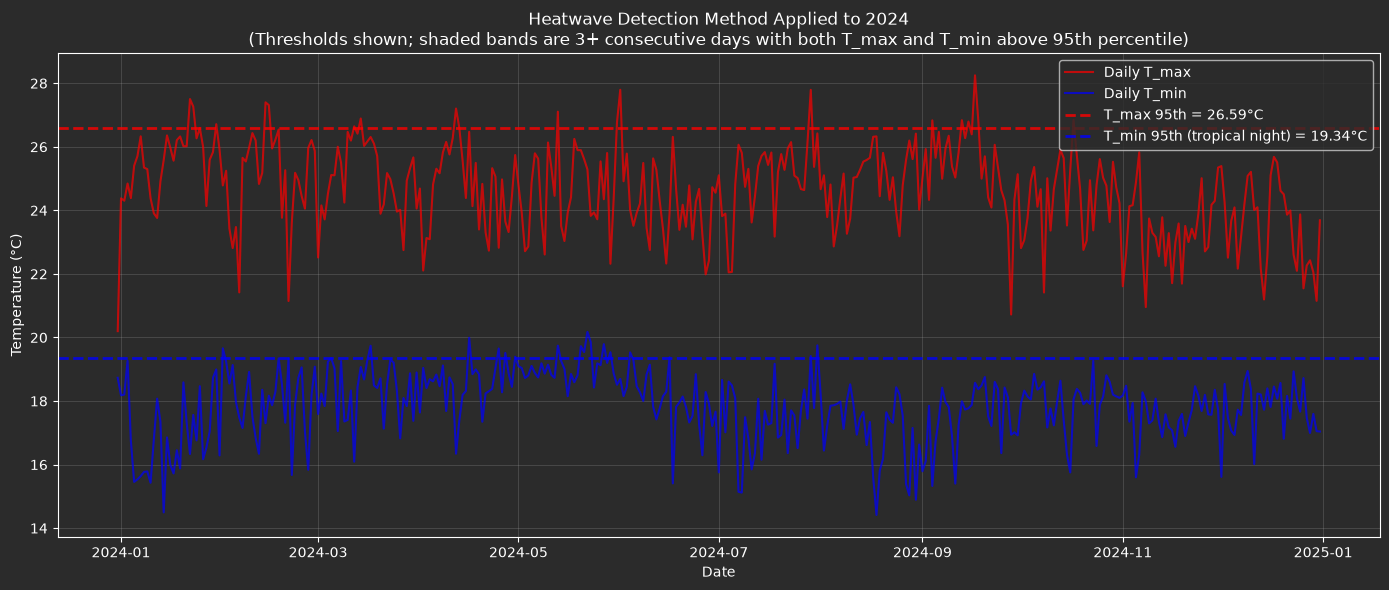

In [39]:
# Create figure with thresholds and event shading
fig, ax = plt.subplots(figsize=(14, 6))

# Plot temperatures
ax.plot(daily_data.index, daily_data["t_max"], label="Daily T_max", linewidth=1.5, color="red", alpha=0.7)
ax.plot(daily_data.index, daily_data["t_min"], label="Daily T_min", linewidth=1.5, color="blue", alpha=0.7)

# Threshold lines
ax.axhline(t_max_95, color="red", linestyle="--", linewidth=2, label=f"T_max 95th = {t_max_95:.2f}°C", alpha=0.8)
ax.axhline(t_min_95, color="blue", linestyle="--", linewidth=2, label=f"T_min 95th (tropical night) = {t_min_95:.2f}°C", alpha=0.8)

# Shade heatwave events
if len(heatwave_events) > 0:
    for _, event in heatwave_events.iterrows():
        start = pd.Timestamp(event["start_date"])
        end = pd.Timestamp(event["end_date"])
        ax.axvspan(start, end, alpha=0.2, color="orange", label="Heatwave" if _ == 0 else "")

ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Heatwave Detection Method Applied to 2024\n(Thresholds shown; shaded bands are 3+ consecutive days with both T_max and T_min above 95th percentile)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — Cool Period Identification

By analogy with heatwave identification, flag cool periods: runs of ≥3 consecutive days where daily T_max falls below the local 5th percentile. This detects anomalously cold spells in the tropics.

In [40]:
# Cool periods: T_max below 5th percentile
cool_days = daily_data["t_max"] < t_max_05

cool_events = []
combined_int = cool_days.astype(int)
transitions = combined_int.diff().fillna(0)

starts = cool_days.index[transitions == 1]
ends = cool_days.index[transitions == -1]
if len(cool_days) > 0 and cool_days.iloc[-1]:
    ends = ends.append(pd.DatetimeIndex([cool_days.index[-1]]))

for start, end in zip(starts, ends):
    duration = (end - start).days + 1
    if duration >= 3:
        cool_events.append({
            "start_date": start.strftime("%Y-%m-%d"),
            "end_date": end.strftime("%Y-%m-%d"),
            "duration_days": duration
        })

cool_events_df = pd.DataFrame(cool_events) if cool_events else pd.DataFrame(columns=["start_date", "end_date", "duration_days"])

print(f"Cool periods in 2024 (T_max < {t_max_05:.2f}°C for ≥3 days):")
print(f"  Total: {len(cool_events_df)}")
if len(cool_events_df) > 0:
    print(f"\n{cool_events_df.to_string(index=False)}")
else:
    print(f"  (None detected)")

print(f"\n  (Single-year threshold; illustrative only.)")

Cool periods in 2024 (T_max < 22.16°C for ≥3 days):
  Total: 0
  (None detected)

  (Single-year threshold; illustrative only.)


## Section 10 — Methodological Summary

This section documents the analytical choices made in this notebook. It will form the basis of the methods section in the final paper.

### Analytical Framework — CaliHeatWaves Layer 1

**Reference point:** 
- Grid cell at (3.500°N, −76.500°W) — nearest ERA5-Land cell to Cali's centre (3.45°N, −76.53°W)
- Single-cell approach justified by resolution limits; spatial heterogeneity deferred to MODIS LST (Layer 3)

**Timezone:**
- Local time (UTC-5, Colombia). No daylight saving time.
- All daily statistics computed on local-time calendar days (00:00–23:59 Colombia time)

**Daily aggregation:**
- T_max = maximum hourly temperature on local-time day
- T_min = minimum hourly temperature on local-time day
- T_mean = mean hourly temperature on local-time day
- Diurnal range = T_max − T_min

**Apparent temperature (when d2m available):**
- Relative humidity computed from t2m and d2m using Magnus formula
- Apparent temperature (heat index) via simplified Steadman: AT = T + (RH/100) × (T − 14) × 0.4 (°C)
- Daily AT_max, AT_min, AT_mean aggregated on local-time days

**Heatwave definition:**
- Event = ≥3 consecutive local-time calendar days where BOTH:
  - Daily T_max > local 95th percentile
  - Daily T_min > local 95th percentile (tropical night)
- Thresholds computed from full 2000–2025 series (not single-year data)

**Cool period definition:**
- Event = ≥3 consecutive days where daily T_max < local 5th percentile
- Detects anomalous cooling; useful for health outcome contrast

**Percentile basis:**
- Derived from the full 2000–2025 climatological series
- This notebook uses 2024 data only for code validation; not for final thresholds

**Quality assurance:**
- Reference cell validated against 3×3 neighbours for edge effects and orographic bias
- Annual cycle and diurnal range inspected for physical plausibility
- Identified events logged with start date, end date, and duration for Layer 2 mortality linkage

---

**Notebook complete.** This analysis establishes the methodological pipeline for Layer 1. Once the full 2000–2025 ERA5-Land data are downloaded and processed, this same code will produce the final thresholds and event chronology used in the mortality analysis (Layer 2) and attribution modeling (Layer 3).